# Diagonal BLR Walkthrough

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/optax_bayes/blob/main/docs/notebooks/diagonal_blr_walkthrough.ipynb)

This notebook demonstrates the standard user path for `optax_bayes`: train a model with `blr_diagonal_for_loss` (a drop-in replacement for `optax.adam`) and then inspect posterior uncertainty via `get_posterior_diagonal`.

**What you'll learn:**

1. How to set up diagonal BLR as an Optax optimizer
2. How to train on a simple quadratic loss
3. How to extract per-parameter posterior mean and variance
4. How the posterior concentrates as training progresses

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "optax_bayes @ git+https://github.com/jejjohnson/optax_bayes@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,optax,optax_bayes",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax        : 0.10.0
optax      : 0.2.8
optax_bayes: 0.1.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

from optax_bayes import blr_diagonal_for_loss, get_posterior_diagonal

## Problem Setup

We minimise a simple quadratic loss $L(\theta) = \frac{1}{2} \|\theta - \theta^*\|^2$ in 5 dimensions.

With the exact Hessian $H = -I$, the analytic BLR fixed-point is $m^* = \theta^* / (1 + s_0)$ and $v^* = 1/(1 + s_0)$. The walkthrough below uses the default `hessian_estimator="ggn_diag"` (i.e. $h = -g^2$), which is a GGN approximation — it matches the mean well but the variance estimate differs from the exact posterior because $h \to 0$ near the optimum. We plot the GGN-BLR mean against the analytic value for reference; the variance estimate is expected to be looser.

In [4]:
d = 5
theta_star = jnp.ones(d) * 3.0
s0 = 1e-4

# Analytic fixed-point assuming the exact Hessian (H = -I).
analytic_m = theta_star / (1 + s0)

print(f"Analytic posterior mean (exact Hessian): {analytic_m[0]:.6f}")


def loss_fn(theta):
    return 0.5 * jnp.sum((theta - theta_star) ** 2)

Analytic posterior mean (exact Hessian): 2.999700


## Training with Diagonal BLR

`blr_diagonal_for_loss` accepts standard loss gradients (like `optax.adam`). Internally it negates them to convert to log-likelihood gradients for the BLR update.

In [5]:
opt = blr_diagonal_for_loss(learning_rate=0.05, prior_precision=s0)
theta = jnp.zeros(d)
state = opt.init(theta)

# Track convergence
history = {"step": [], "loss": [], "mean_0": [], "var_0": []}

for i in range(500):
    grads = jax.grad(loss_fn)(theta)
    updates, state = opt.update(grads, state)
    theta = optax.apply_updates(theta, updates)

    if (i + 1) % 25 == 0:
        m, v = get_posterior_diagonal(state)
        history["step"].append(i + 1)
        history["loss"].append(float(loss_fn(theta)))
        history["mean_0"].append(float(m[0]))
        history["var_0"].append(float(v[0]))

# Final posterior
m_final, v_final = get_posterior_diagonal(state)
print(f"Final mean[0]:     {m_final[0]:.6f}  (analytic: {analytic_m[0]:.6f})")
print(f"Final variance[0]: {v_final[0]:.6f}  (GGN estimate)")

Final mean[0]:     2.841810  (analytic: 2.999700)
Final variance[0]: 40.000725  (GGN estimate)


## Convergence Plots

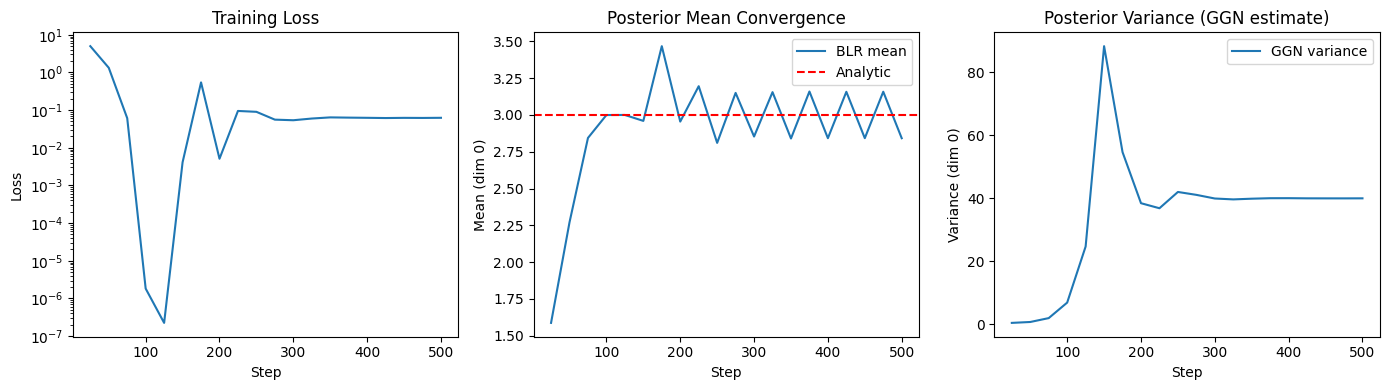

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].semilogy(history["step"], history["loss"])
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")

axes[1].plot(history["step"], history["mean_0"], label="BLR mean")
axes[1].axhline(analytic_m[0], color="r", linestyle="--", label="Analytic")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Mean (dim 0)")
axes[1].set_title("Posterior Mean Convergence")
axes[1].legend()

axes[2].plot(history["step"], history["var_0"], label="GGN variance")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Variance (dim 0)")
axes[2].set_title("Posterior Variance (GGN estimate)")
axes[2].legend()

plt.tight_layout()
plt.show()

## Optax Composition

`blr_diagonal_for_loss` composes naturally with other Optax transforms:

In [7]:
opt_clipped = optax.chain(
    optax.clip_by_global_norm(1.0),
    blr_diagonal_for_loss(learning_rate=0.01, prior_precision=1e-4),
)

theta2 = jnp.zeros(d)
state2 = opt_clipped.init(theta2)

for _ in range(200):
    grads = jax.grad(loss_fn)(theta2)
    updates, state2 = opt_clipped.update(grads, state2)
    theta2 = optax.apply_updates(theta2, updates)

# Extract posterior from the inner BLR state (second element in chain)
blr_state = state2[1]
m2, v2 = get_posterior_diagonal(blr_state)
print(f"Clipped BLR mean[0]:     {m2[0]:.4f}")
print(f"Clipped BLR variance[0]: {v2[0]:.6f}")

Clipped BLR mean[0]:     3.0168
Clipped BLR variance[0]: 195.068314


## Summary

1. **Drop-in replacement**: `blr_diagonal_for_loss` works like `optax.adam` — same `init`/`update`/`apply_updates` loop.
2. **Posterior for free**: `get_posterior_diagonal(state)` returns per-parameter mean and variance at any point during training.
3. **Composable**: Chain with `optax.clip_by_global_norm`, schedules, or any Optax transform.